# Treinamento Final do Modelo

Pipeline completa com os melhores hiperparâmetros do AG (03/Exp2_padrao), calibração isotônica e exportação de SHAP para a API.

In [5]:
import sys
sys.path.insert(0, '..')

import json
import pickle
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import shap
import matplotlib.pyplot as plt
from pathlib import Path

from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import recall_score, fbeta_score, precision_score, roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.utils.class_weight import compute_sample_weight

from src.cleaning import clean_dataset
from src.constants import DEFAULT_THRESHOLD, RANDOM_STATE
from src.pipeline_factory import build_pipeline

ARTIFACTS_DIR = Path('../results/artifacts')
METRICS_DIR   = Path('../results/metrics')
ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)

print('shap:', shap.__version__)
print('ARTIFACTS_DIR:', ARTIFACTS_DIR.resolve())

shap: 0.52.0
ARTIFACTS_DIR: /home/emidiosouza/FiapCode/fase2/tech-challenge-fase-2/results/artifacts


## 1. Dados

In [6]:
df_raw   = pd.read_parquet('../data/df_model_raw.parquet')
df_clean = clean_dataset(df_raw)

y = df_clean['PREMATURO']
X = df_clean.drop(columns=['PREMATURO'])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)

print(f'Train: {X_train.shape}  |  Test: {X_test.shape}')
print(f'Prevalência prematuro (treino): {y_train.mean():.3%}')
print(f'Features: {X_train.columns.tolist()}')

Train: (552344, 12)  |  Test: (138087, 12)
Prevalência prematuro (treino): 10.201%
Features: ['IDADEMAE', 'ESCMAE2010', 'QTDGESTANT', 'QTDPARTNOR', 'QTDPARTCES', 'QTDFILVIVO', 'QTDFILMORT', 'MESPRENAT', 'KOTELCHUCK', 'LATITUDE', 'LONGITUDE', 'PAI_AUSENTE']


## 2. Pipeline não calibrada — base para SHAP

Treinamos a pipeline completa sem calibração para extrair o HistGB e calcular SHAP com `TreeExplainer`.  
A calibração isotônica altera as probabilidades mas não os rankings de importância — SHAP sobre o modelo base é representativo.

In [7]:
sample_weights = compute_sample_weight(class_weight='balanced', y=y_train)

pipe_base = build_pipeline()
pipe_base.fit(
    X_train, y_train,
    histgradientboostingclassifier__sample_weight=sample_weights,
)

# Componentes internos para SHAP
preprocessor   = Pipeline(pipe_base.steps[:-1])          # FeatureEngineer + ColumnTransformer
histgb         = pipe_base.named_steps['histgradientboostingclassifier']
feature_names  = list(pipe_base['preprocessor'].get_feature_names_out())

print('Features após pré-processamento:', feature_names)

Features após pré-processamento: ['IDADEMAE', 'QTDGESTANT', 'QTDPARTNOR', 'QTDPARTCES', 'QTDFILVIVO', 'QTDFILMORT', 'MESPRENAT', 'LATITUDE', 'LONGITUDE', 'ESCMAE2010_ORDINAL', 'KOTELCHUCK_ORDINAL', 'PAI_AUSENTE']


## 3. SHAP

In [8]:
# Pré-processa dados para o explainer
X_test_prep  = preprocessor.transform(X_test)
X_train_prep = preprocessor.transform(X_train)

# Amostras para background (100) e para cálculo de SHAP values (2000)
rng = np.random.default_rng(RANDOM_STATE)
bg_idx    = rng.choice(len(X_train_prep), size=100,  replace=False)
shap_idx  = rng.choice(len(X_test_prep),  size=2000, replace=False)

X_background  = pd.DataFrame(X_train_prep[bg_idx],   columns=feature_names)
X_shap_sample = pd.DataFrame(X_test_prep[shap_idx],  columns=feature_names)

explainer = shap.TreeExplainer(histgb, data=X_background)
# check_additivity=False: HistGB usa bins internos que causam discrepância numérica leve
explanation = explainer(X_shap_sample, check_additivity=False)

# Para classificação binária, SHAP retorna (n, features) ou (n, features, 2)
shap_vals = explanation.values
if shap_vals.ndim == 3:
    shap_vals = shap_vals[:, :, 1]

print(f'shap_values shape: {shap_vals.shape}')
mean_abs = np.abs(shap_vals).mean(axis=0)
print('Top 5 features por |SHAP| médio:')
for i in np.argsort(mean_abs)[::-1][:5]:
    print(f'  {feature_names[i]}: {mean_abs[i]:.4f}')

shap_values shape: (2000, 12)
Top 5 features por |SHAP| médio:
  KOTELCHUCK_ORDINAL: 0.3913
  QTDFILVIVO: 0.1577
  MESPRENAT: 0.1326
  IDADEMAE: 0.1164
  LONGITUDE: 0.0790


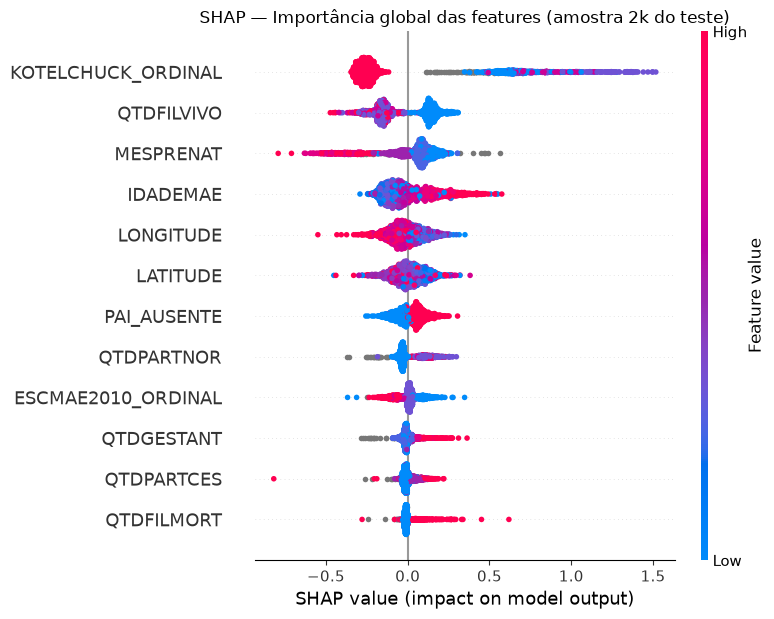

In [9]:
shap.summary_plot(shap_vals, X_shap_sample, show=False)
plt.title('SHAP — Importância global das features (amostra 2k do teste)')
plt.tight_layout()
plt.savefig('../results/figures/07_shap_summary.png', dpi=120, bbox_inches='tight')
plt.show()

## 4. Calibração isotônica — modelo final

In [10]:
calibrated_model = CalibratedClassifierCV(build_pipeline(), method='isotonic', cv=3)
calibrated_model.fit(X_train, y_train, sample_weight=sample_weights)
print('Modelo calibrado treinado.')

Modelo calibrado treinado.


## 5. Avaliação final no conjunto de teste

In [11]:
y_prob = calibrated_model.predict_proba(X_test)[:, 1]
y_pred = (y_prob >= DEFAULT_THRESHOLD).astype(int)

tp = int(((y_pred == 1) & (y_test == 1)).sum())
fn = int(((y_pred == 0) & (y_test == 1)).sum())
fp = int(((y_pred == 1) & (y_test == 0)).sum())

metrics = {
    'threshold': DEFAULT_THRESHOLD,
    'recall':    round(recall_score(y_test, y_pred), 4),
    'f2':        round(fbeta_score(y_test, y_pred, beta=2), 4),
    'precision': round(precision_score(y_test, y_pred, zero_division=0), 4),
    'roc_auc':   round(roc_auc_score(y_test, y_prob), 4),
    'tp': tp, 'fn': fn, 'fp': fp,
}

with open(METRICS_DIR / 'best_model_operational_metrics_phase2.json', 'w') as f:
    json.dump({'model': '03_Exp2_padrao_calibrated', 'metrics': metrics}, f, indent=2)

print(f"recall:    {metrics['recall']}")
print(f"f2:        {metrics['f2']}")
print(f"precision: {metrics['precision']}")
print(f"roc_auc:   {metrics['roc_auc']}")
print(f"TP={tp}  FN={fn}  FP={fp}")

recall:    0.8279
f2:        0.3805
precision: 0.1203
roc_auc:   0.6517
TP=11662  FN=2424  FP=85255


## 6. Salvar artefatos

| Arquivo | Conteúdo |
|---|---|
| `model_phase2.pkl` | `CalibratedClassifierCV` completa (aceita DataFrame bruto) |
| `shap_bundle.pkl` | `{'explainer': TreeExplainer, 'preprocessor': Pipeline, 'feature_names': list}` |
| `shap_values_sample.npy` | SHAP values de 2 000 amostras do teste (para validação/viz) |

In [12]:
shap_bundle = {
    'explainer':     explainer,
    'preprocessor':  preprocessor,
    'feature_names': feature_names,
}

with open(ARTIFACTS_DIR / 'model_phase2.pkl',        'wb') as f: pickle.dump(calibrated_model, f)
with open(ARTIFACTS_DIR / 'shap_bundle.pkl',         'wb') as f: pickle.dump(shap_bundle, f)
np.save(ARTIFACTS_DIR / 'shap_values_sample.npy', shap_vals)

print('Artefatos salvos:')
for p in sorted(ARTIFACTS_DIR.iterdir()):
    print(f'  {p.name}  ({p.stat().st_size / 1024:.0f} KB)')

Artefatos salvos:
  best_model_calibrated.pkl  (2243 KB)
  model_phase2.pkl  (1261 KB)
  shap_bundle.pkl  (621 KB)
  shap_values_sample.npy  (188 KB)
